# Task 2: Credit Risk Prediction (Loan Default Classification)

---

## Introduction & Problem Statement

Credit risk assessment is one of the most critical challenges in the banking and financial sector.  
Every time a bank issues a loan, it faces the risk that the borrower may **default** (fail to repay).

### Objective
> **Predict whether a loan applicant is likely to default on a loan** using historical borrower data.

This is a **binary classification problem**:
- `loan_paid_back = 1` → Loan was repaid ✅ (No Default)
- `loan_paid_back = 0` → Loan was NOT repaid ❌ (Default)

### Dataset
- **Source:** Loan Prediction Dataset (Kaggle)
- **Records:** 20,000 loan applicants
- **Features:** 22 columns including demographic, financial, and loan-specific attributes

### Skills Demonstrated
| Skill | Description |
|---|---|
| Data Cleaning | Handling missing values, encoding, scaling |
| EDA | Visualizing distributions, correlations, patterns |
| ML Classification | Logistic Regression & Decision Tree |
| Model Evaluation | Accuracy, Confusion Matrix, ROC-AUC, Classification Report |


## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

C_DEF     = '#E74C3C'   # red  — default
C_PAID    = '#2ECC71'   # green — paid
C_PRIMARY = '#2C3E50'
C_ACCENT  = '#3498DB'

print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Dataset Loading & Understanding

In [3]:
df = pd.read_csv('LoanPredictionDataset.csv')

print(f"Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("─" * 50)
df.head()


Dataset Shape : 20,000 rows × 22 columns
──────────────────────────────────────────────────


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [4]:
print("Column Info:")
df.info()


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of

In [5]:
print("Statistical Summary:")
df.describe().round(2)


Statistical Summary:


,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.0
mean,48.03,43549.64,3629.14,0.18,679.26,15129.30,12.40,43.22,455.63,5.01,48649.82,24333.39,1.99,0.06,2.49,0.8
std,15.83,28668.58,2389.05,0.11,69.64,8605.41,2.44,11.01,274.62,2.24,32423.38,22313.85,1.47,0.29,1.63,0.4
min,21.00,6000.00,500.00,0.01,373.00,500.00,3.14,36.00,9.43,0.00,6157.80,496.35,0.00,0.00,0.00,0.0
25%,35.00,24260.75,2021.73,0.10,632.00,8852.70,10.74,36.00,253.91,3.00,27180.49,9592.57,1.00,0.00,1.00,1.0
50%,48.00,36585.26,3048.77,0.16,680.00,14946.17,12.40,36.00,435.60,5.00,40241.62,18334.56,2.00,0.00,2.00,1.0
75%,62.00,54677.92,4556.50,0.24,727.00,20998.87,14.00,60.00,633.60,6.00,60361.26,31743.33,3.00,0.00,3.00,1.0
max,75.00,400000.00,33333.33,0.67,850.00,49039.69,22.51,60.00,1685.40,15.00,454394.19,352177.90,11.00,2.00,11.00,1.0


In [6]:
counts = df['loan_paid_back'].value_counts()
print("Target Variable Distribution:")
print(f"Loan Paid Back (1) : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")
print(f"Default       (0) : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")


Target Variable Distribution:
Loan Paid Back (1) : 15,998  (80.0%)
Default       (0) : 4,002  (20.0%)


## 3. Data Cleaning & Preparation

In [7]:
# ─── Check for Missing Values ─────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in the dataset!")


Missing Values per Column:
No missing values found in the dataset!


In [8]:
# ─── Check for Duplicate Rows ─────────────────────────────────────────────────
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed. New shape: {df.shape}")
else:
    print("No duplicates found.")


Duplicate rows: 0
No duplicates found.


In [9]:
# ─── Identify Categorical & Numerical Columns ──────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns
            if c != 'loan_paid_back']
print(f"Categorical ({len(cat_cols)}): {cat_cols}")
print(f"Numerical   ({len(num_cols)}): {num_cols}")


Categorical (6): ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
Numerical   (15): ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies']


In [10]:
# ─── Unique values in categorical columns ──────────────────────────────────────
print("Unique values:")
for col in cat_cols:
    print(f"  {col:25s}: {df[col].unique().tolist()}")


Unique values:
  gender                   : ['Male', 'Female', 'Other']
  marital_status           : ['Married', 'Single', 'Divorced', 'Widowed']
  education_level          : ["Master's", "Bachelor's", 'High School', 'Other', 'PhD']
  employment_status        : ['Employed', 'Unemployed', 'Self-employed', 'Student', 'Retired']
  loan_purpose             : ['Car', 'Debt consolidation', 'Business', 'Other', 'Home', 'Medical', 'Education', 'Vacation']
  grade_subgrade           : ['B5', 'F1', 'B4', 'A5', 'D5', 'B1', 'B3', 'A3', 'C4', 'C3', 'C2', 'D4', 'D3', 'C1', 'E3', 'F4', 'C5', 'F3', 'F5', 'A2', 'D2', 'A4', 'E5', 'D1', 'E1', 'E2', 'B2', 'E4', 'F2', 'A1']


In [11]:
# ─── Label Encode Categorical Variables ───────────────────────────────────────
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"Encoded '{col}'")
print("\nAll categorical columns encoded!")


Encoded 'gender'
Encoded 'marital_status'
Encoded 'education_level'
Encoded 'employment_status'
Encoded 'loan_purpose'
Encoded 'grade_subgrade'

All categorical columns encoded!


In [12]:
# ─── Handle Outliers via IQR Capping (Winsorization) ─────────────────────────
def cap_outliers(data, col):
    """Cap extreme values at 1.5×IQR fence values."""
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    data[col] = data[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return data
for col in ['annual_income', 'loan_amount', 'credit_score', 'debt_to_income_ratio']:
    df_encoded = cap_outliers(df_encoded, col)
    print(f"Outliers capped: {col}")


Outliers capped: annual_income
Outliers capped: loan_amount
Outliers capped: credit_score
Outliers capped: debt_to_income_ratio


In [13]:
# ─── Feature / Target Split ────────────────────────────────────────────────────
X = df_encoded.drop('loan_paid_back', axis=1)
y = df_encoded['loan_paid_back']

# ─── Train-Test Split (80 / 20) ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"X shape     : {X.shape}")
print(f"Train set   : {X_train.shape[0]:,} samples")
print(f"Test  set   : {X_test.shape[0]:,} samples")

# ─── Scale Features (for Logistic Regression) ─────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("StandardScaler applied (fit on train, transform on test)")


X shape     : (20000, 21)
Train set   : 16,000 samples
Test  set   : 4,000 samples
StandardScaler applied (fit on train, transform on test)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

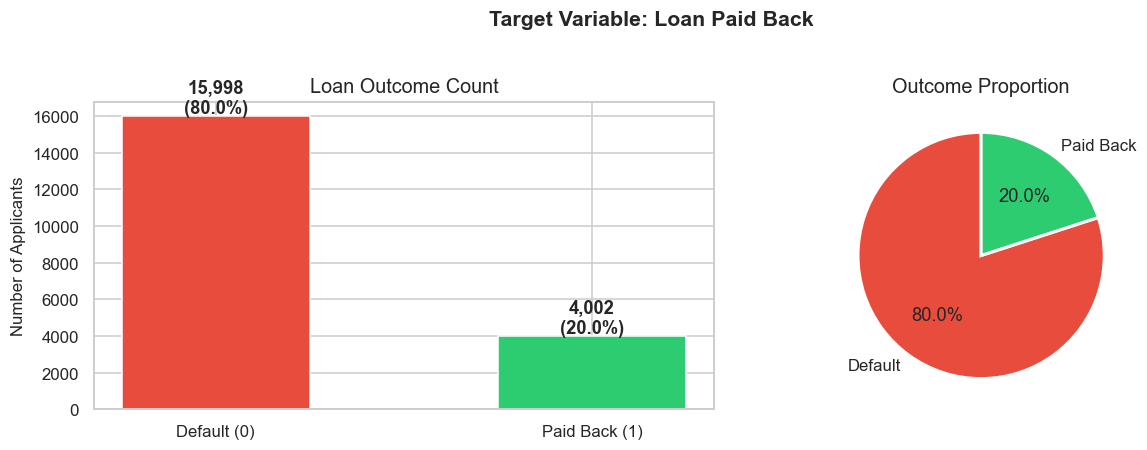

📌 Insight: ~80% paid back vs ~20% defaults class imbalance present.


In [14]:
# ─── EDA 1: Target Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['loan_paid_back'].value_counts()
axes[0].bar(['Default (0)', 'Paid Back (1)'], counts.values,
            color=[C_DEF, C_PAID], edgecolor='white', width=0.5)
axes[0].set_title('Loan Outcome Count')
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Default', 'Paid Back'],
            colors=[C_DEF, C_PAID], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Outcome Proportion')

fig.suptitle('Target Variable: Loan Paid Back', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_target_distribution.png', bbox_inches='tight')
plt.show()
print("📌 Insight: ~80% paid back vs ~20% defaults class imbalance present.")


### 4.2 Loan Amount

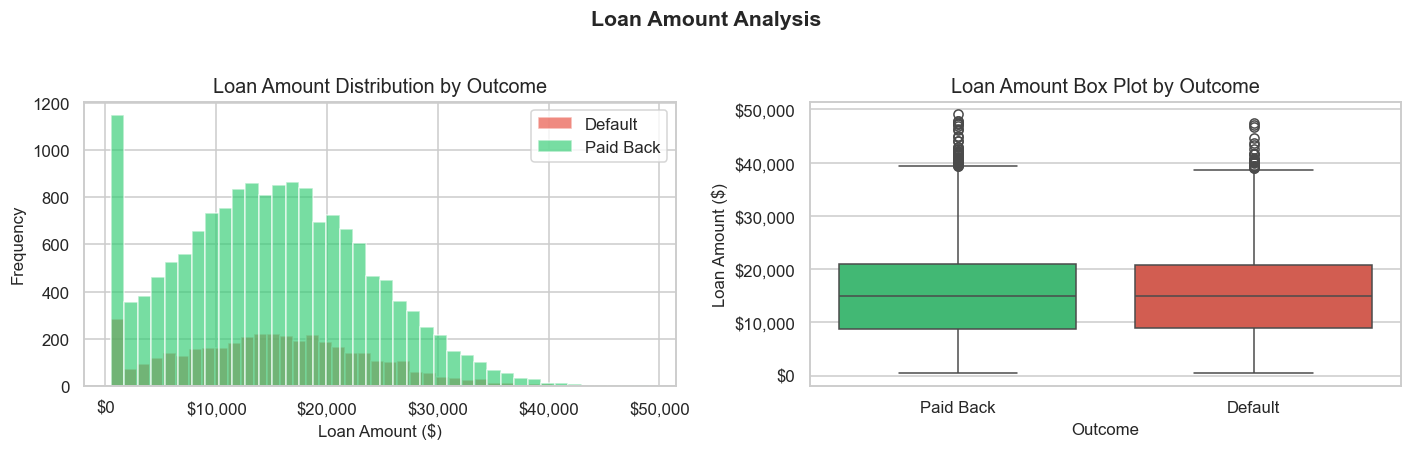

📌 Insight: Defaulters tend to have slightly higher loan amounts.


In [15]:
# ─── EDA 2: Loan Amount ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0, C_DEF, 'Default'), (1, C_PAID, 'Paid Back')]:
    axes[0].hist(df[df['loan_paid_back']==label]['loan_amount'],
                 bins=40, alpha=0.65, color=color, label=name)
axes[0].set_title('Loan Amount Distribution by Outcome')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Box plot — convert target to string for seaborn palette dict
df_plot = df.copy()
df_plot['outcome'] = df_plot['loan_paid_back'].map({0:'Default', 1:'Paid Back'})
sns.boxplot(data=df_plot, x='outcome', y='loan_amount',
            palette={'Default': C_DEF, 'Paid Back': C_PAID}, ax=axes[1])
axes[1].set_title('Loan Amount Box Plot by Outcome')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Loan Amount ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.suptitle('Loan Amount Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_loan_amount.png', bbox_inches='tight')
plt.show()
print("📌 Insight: Defaulters tend to have slightly higher loan amounts.")


### 4.3 Education Level

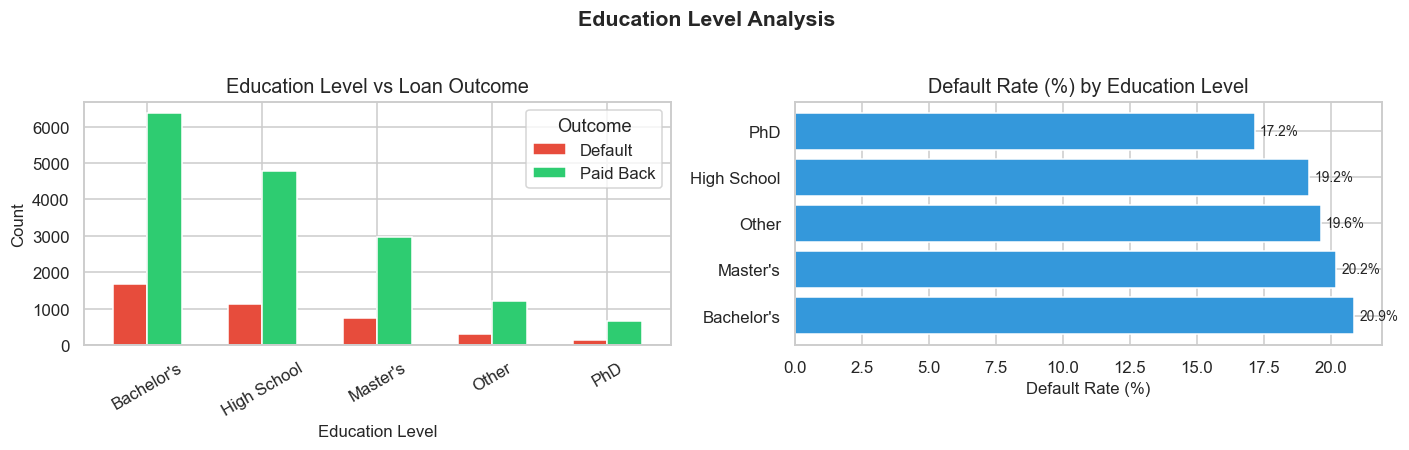

📌 Insight: Education level affects default probability.


In [16]:
# ─── EDA 3: Education Level ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

edu_counts = df.groupby(['education_level','loan_paid_back']).size().unstack()
edu_counts.plot(kind='bar', ax=axes[0], color=[C_DEF, C_PAID], edgecolor='white', width=0.6)
axes[0].set_title('Education Level vs Loan Outcome')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Count')
axes[0].legend(['Default','Paid Back'], title='Outcome')
axes[0].tick_params(axis='x', rotation=30)

default_rate = df.groupby('education_level')['loan_paid_back'].apply(
    lambda x: (x==0).sum()/len(x)*100).sort_values(ascending=False)
axes[1].barh(default_rate.index, default_rate.values, color=C_ACCENT, edgecolor='white')
axes[1].set_title('Default Rate (%) by Education Level')
axes[1].set_xlabel('Default Rate (%)')
for i, v in enumerate(default_rate.values):
    axes[1].text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=9)

fig.suptitle('Education Level Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_education.png', bbox_inches='tight')
plt.show()
print("📌 Insight: Education level affects default probability.")


### 4.2 Annual Income

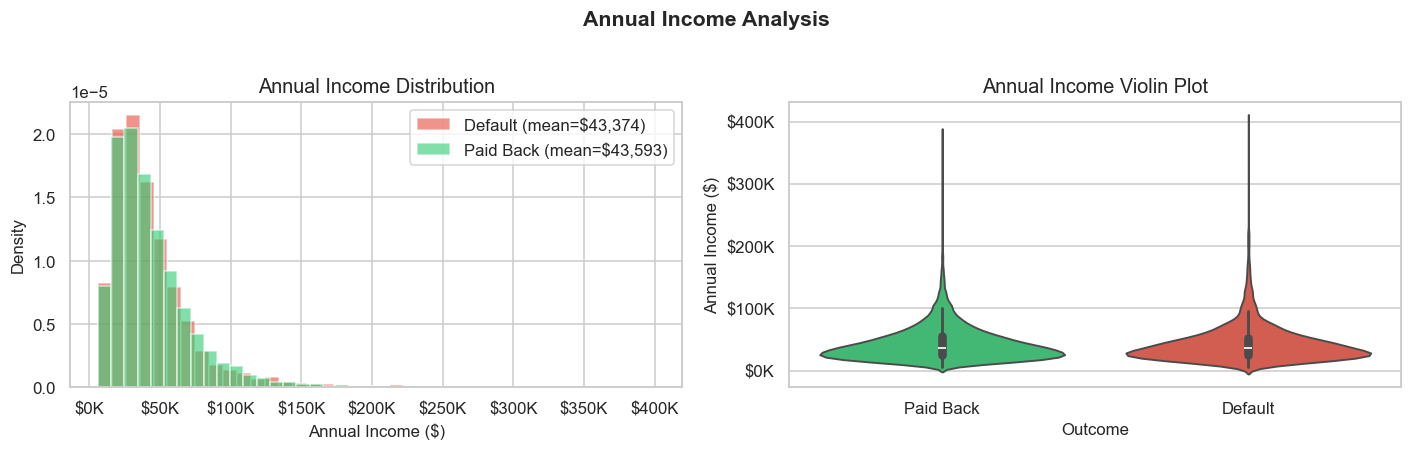

📌 Insight: Lower-income applicants show slightly higher default rates.


In [17]:
# ─── EDA 4: Annual Income ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0, C_DEF, 'Default'), (1, C_PAID, 'Paid Back')]:
    subset = df[df['loan_paid_back']==label]['annual_income']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, density=True,
                 label=f'{name} (mean=${subset.mean():,.0f})')
axes[0].set_title('Annual Income Distribution')
axes[0].set_xlabel('Annual Income ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Violin — use string outcome column
df_plot = df.copy()
df_plot['outcome'] = df_plot['loan_paid_back'].map({0:'Default', 1:'Paid Back'})
sns.violinplot(data=df_plot, x='outcome', y='annual_income',
               palette={'Default': C_DEF, 'Paid Back': C_PAID}, ax=axes[1])
axes[1].set_title('Annual Income Violin Plot')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Annual Income ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

fig.suptitle('Annual Income Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_income.png', bbox_inches='tight')
plt.show()
print("📌 Insight: Lower-income applicants show slightly higher default rates.")


### 4.5 Credit Score

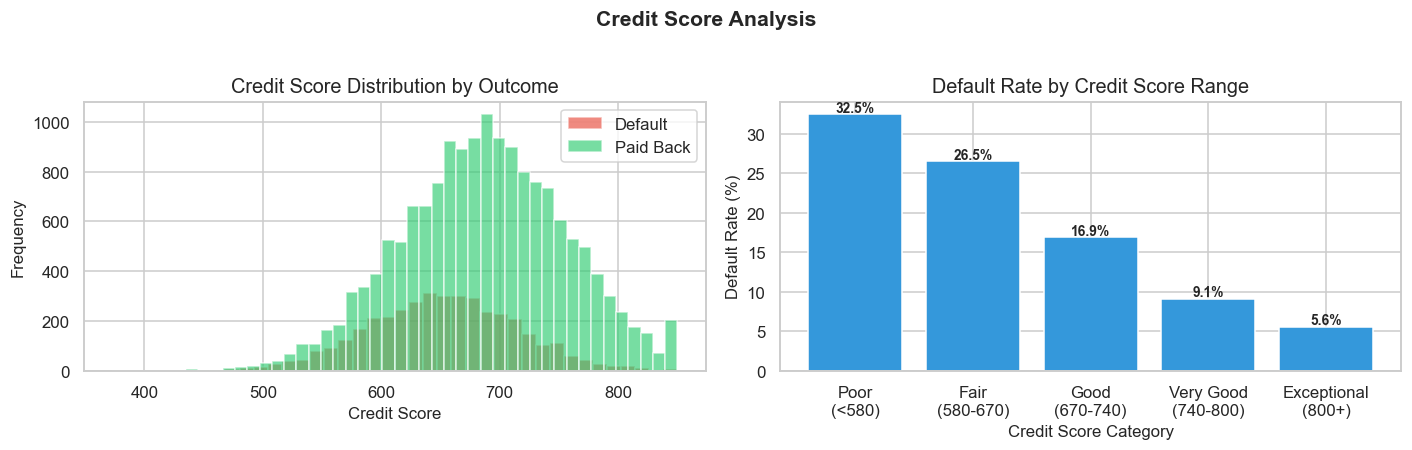

📌 Insight: Lower credit scores strongly correlate with higher default rates.


In [18]:
# ─── EDA 5: Credit Score ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0, C_DEF, 'Default'), (1, C_PAID, 'Paid Back')]:
    axes[0].hist(df[df['loan_paid_back']==label]['credit_score'],
                 bins=40, alpha=0.65, color=color, label=name)
axes[0].set_title('Credit Score Distribution by Outcome')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

bins   = [300, 580, 670, 740, 800, 850]
labels_b = ['Poor\n(<580)','Fair\n(580-670)','Good\n(670-740)',
             'Very Good\n(740-800)','Exceptional\n(800+)']
df_tmp = df.copy()
df_tmp['credit_bin'] = pd.cut(df_tmp['credit_score'], bins=bins, labels=labels_b)
bin_default = df_tmp.groupby('credit_bin', observed=True)['loan_paid_back'].apply(
    lambda x: (x==0).mean()*100)
axes[1].bar(range(len(bin_default)), bin_default.values,
            color=C_ACCENT, edgecolor='white', tick_label=bin_default.index.tolist())
axes[1].set_title('Default Rate by Credit Score Range')
axes[1].set_xlabel('Credit Score Category')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(bin_default.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Credit Score Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_credit_score.png', bbox_inches='tight')
plt.show()
print("📌 Insight: Lower credit scores strongly correlate with higher default rates.")


### 4.6 Correlation Heatmap

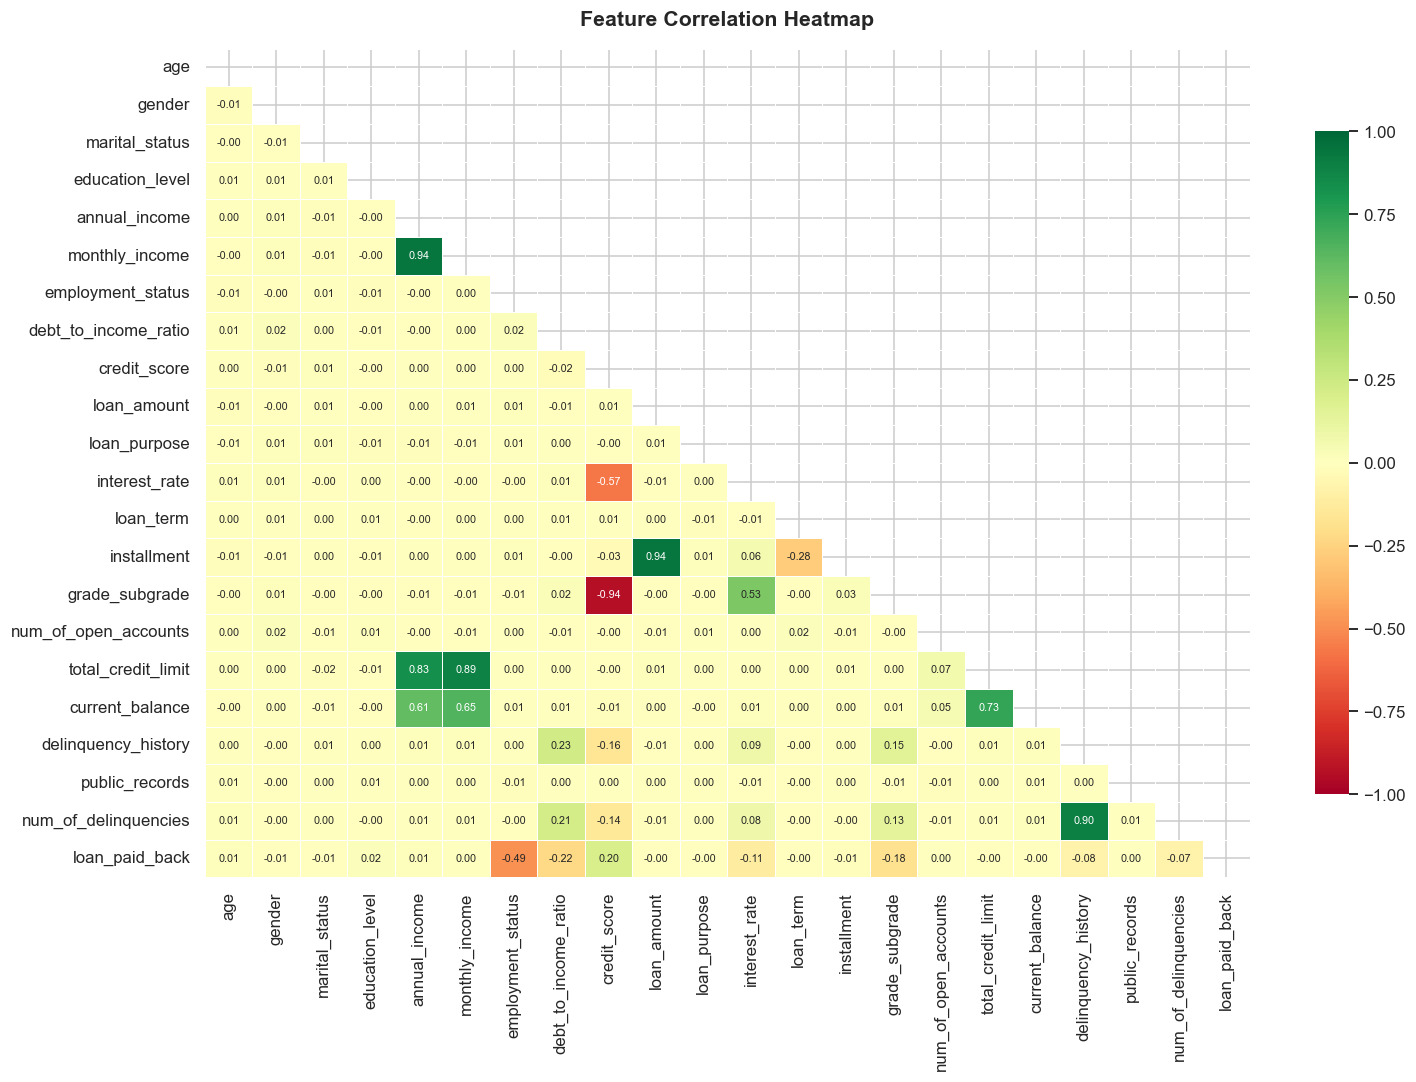

📌 Insight: annual_income & monthly_income are highly correlated.
   credit_score has positive correlation with loan_paid_back.


In [19]:
# ─── EDA 6: Correlation Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, ax=ax,
            annot_kws={'size': 7}, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()
print("📌 Insight: annual_income & monthly_income are highly correlated.")
print("   credit_score has positive correlation with loan_paid_back.")


### 4.7 Employment, Loan Purpose, Gender

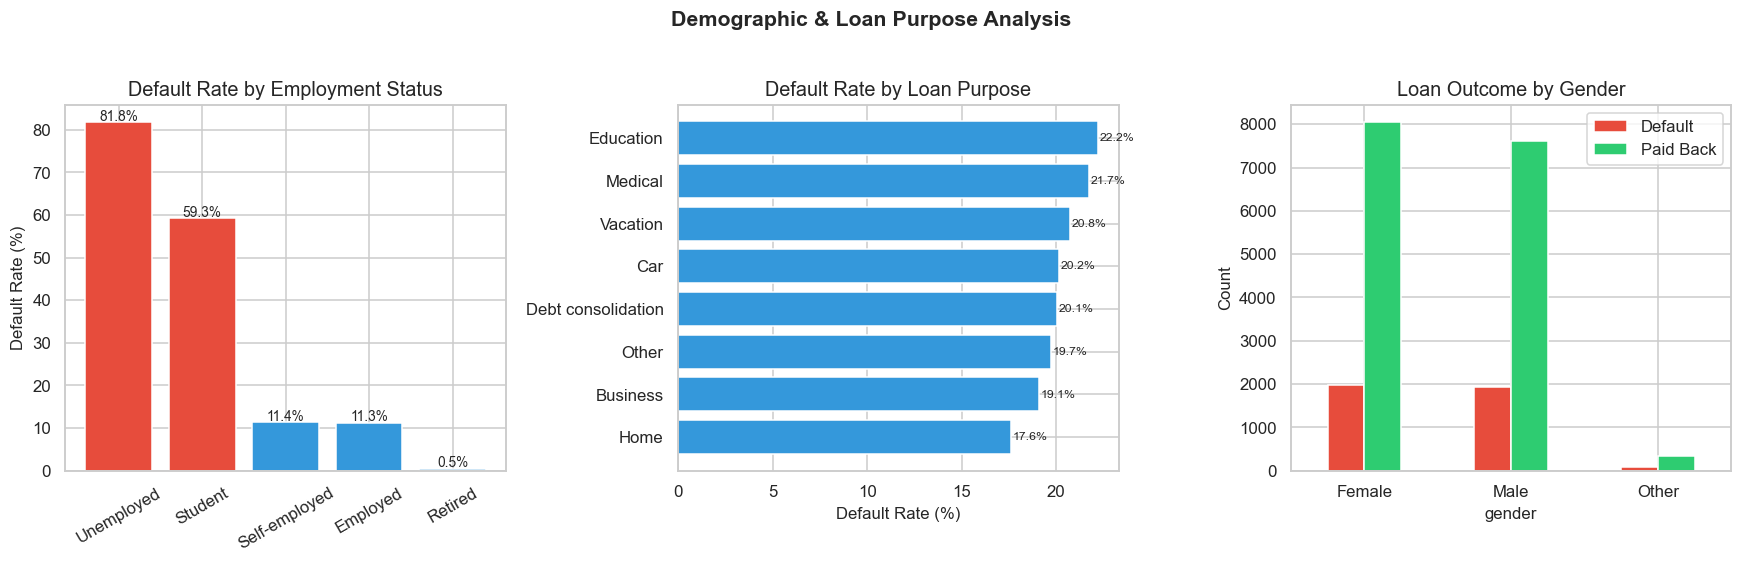

In [20]:
# ─── EDA 7: Employment, Loan Purpose, Gender ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Employment Status default rate
emp_rate = df.groupby('employment_status')['loan_paid_back'].apply(
    lambda x: (x==0).mean()*100).sort_values(ascending=False)
colors_bar = [C_DEF if v > emp_rate.mean() else C_ACCENT for v in emp_rate.values]
axes[0].bar(emp_rate.index, emp_rate.values, color=colors_bar, edgecolor='white')
axes[0].set_title('Default Rate by Employment Status')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(emp_rate.values):
    axes[0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Loan Purpose
purpose_default = df.groupby('loan_purpose')['loan_paid_back'].apply(
    lambda x: (x==0).mean()*100).sort_values()
axes[1].barh(purpose_default.index, purpose_default.values, color=C_ACCENT, edgecolor='white')
axes[1].set_title('Default Rate by Loan Purpose')
axes[1].set_xlabel('Default Rate (%)')
for i, v in enumerate(purpose_default.values):
    axes[1].text(v+0.1, i, f'{v:.1f}%', va='center', fontsize=8)

# Gender
gender_data = df.groupby(['gender','loan_paid_back']).size().unstack()
gender_data.plot(kind='bar', ax=axes[2], color=[C_DEF, C_PAID], edgecolor='white')
axes[2].set_title('Loan Outcome by Gender')
axes[2].set_ylabel('Count')
axes[2].legend(['Default','Paid Back'])
axes[2].tick_params(axis='x', rotation=0)

fig.suptitle('Demographic & Loan Purpose Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_demographics.png', bbox_inches='tight')
plt.show()


## 5. Model Training & Testing

In [21]:
# ─── Model 1: Logistic Regression (uses scaled features) ─────────────────────
print("=" * 35)
print("  MODEL 1: LOGISTIC REGRESSION")
print("=" * 35)

lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_sc, y_train)

y_pred_lr = lr_model.predict(X_test_sc)
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print(f"\n  Training Accuracy : {lr_model.score(X_train_sc, y_train)*100:.2f}%")
print(f"  Testing  Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"  ROC-AUC Score    : {roc_auc_score(y_test, y_prob_lr):.4f}")


  MODEL 1: LOGISTIC REGRESSION

  Training Accuracy : 88.70%
  Testing  Accuracy : 88.60%
  ROC-AUC Score    : 0.8521


In [23]:
# ─── Model 2: Decision Tree (does NOT need scaling) ───────────────────────────
print("=" * 40)
print("  MODEL 2: DECISION TREE CLASSIFIER")
print("=" * 40)

dt_model = DecisionTreeClassifier(max_depth=6, min_samples_split=50,
                                   min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print(f"\n  Training Accuracy : {dt_model.score(X_train, y_train)*100:.2f}%")
print(f"  Testing  Accuracy : {accuracy_score(y_test, y_pred_dt)*100:.2f}%")
print(f"  ROC-AUC Score    : {roc_auc_score(y_test, y_prob_dt):.4f}")


  MODEL 2: DECISION TREE CLASSIFIER

  Training Accuracy : 90.08%
  Testing  Accuracy : 89.85%
  ROC-AUC Score    : 0.8725


## 6. Evaluation Metrics

In [24]:
# ─── Classification Reports ───────────────────────────────────────────────────
print("━" * 50)
print("  LOGISTIC REGRESSION: Classification Report")
print("━" * 50)
print(classification_report(y_test, y_pred_lr, target_names=['Default (0)', 'Paid Back (1)']))

print("━" * 45)
print("  DECISION TREE: Classification Report")
print("━" * 45)
print(classification_report(y_test, y_pred_dt, target_names=['Default (0)', 'Paid Back (1)']))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LOGISTIC REGRESSION: Classification Report
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
               precision    recall  f1-score   support

  Default (0)       0.81      0.56      0.66       800
Paid Back (1)       0.90      0.97      0.93      3200

     accuracy                           0.89      4000
    macro avg       0.85      0.76      0.80      4000
 weighted avg       0.88      0.89      0.88      4000

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DECISION TREE: Classification Report
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
               precision    recall  f1-score   support

  Default (0)       0.94      0.53      0.67       800
Paid Back (1)       0.89      0.99      0.94      3200

     accuracy                           0.90      4000
    macro avg       0.92      0.76      0.81      4000
 weighted avg       0.90      0.90      0.89      4000



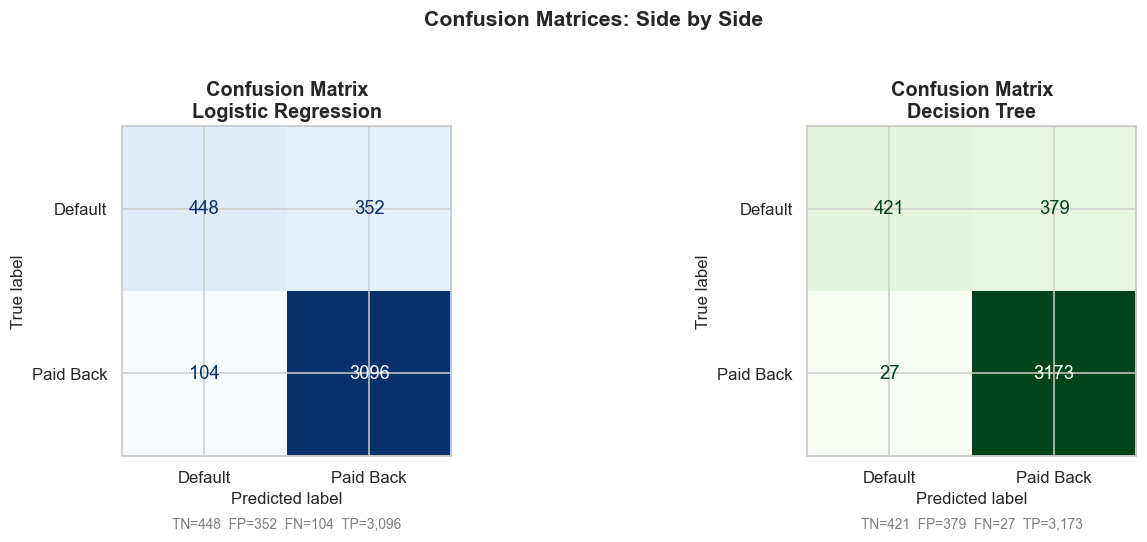

In [26]:
# ─── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, name, cmap in [
        (axes[0], y_pred_lr, 'Logistic Regression', 'Blues'),
        (axes[1], y_pred_dt, 'Decision Tree',        'Greens')]:
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Default', 'Paid Back'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.22, f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}',
            ha='center', transform=ax.transAxes, fontsize=9, color='gray')

fig.suptitle('Confusion Matrices: Side by Side', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', bbox_inches='tight')
plt.show()


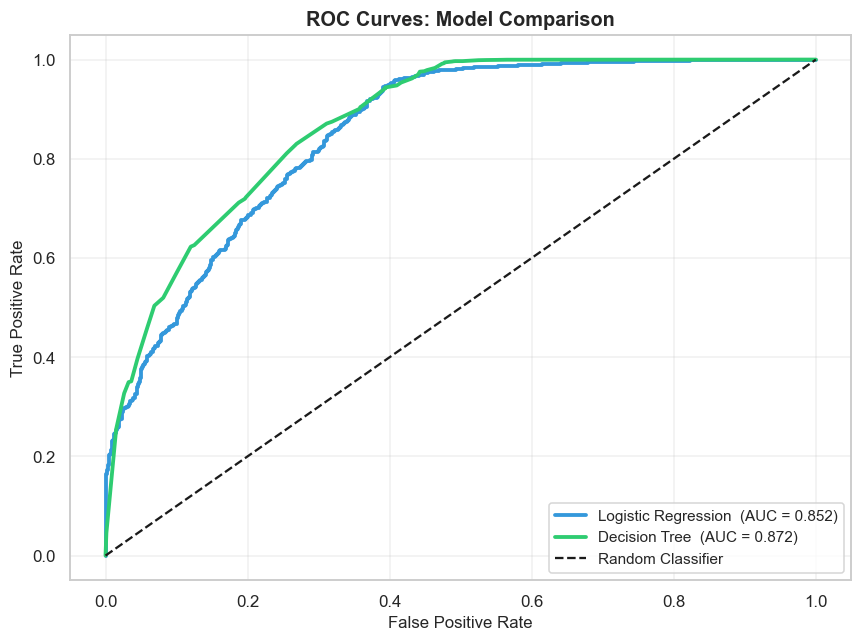

In [27]:
# ─── ROC Curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, name, color in [(y_prob_lr, 'Logistic Regression', C_ACCENT),
                              (y_prob_dt, 'Decision Tree',       C_PAID)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
ax.set_title('ROC Curves: Model Comparison', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_roc_curves.png', bbox_inches='tight')
plt.show()


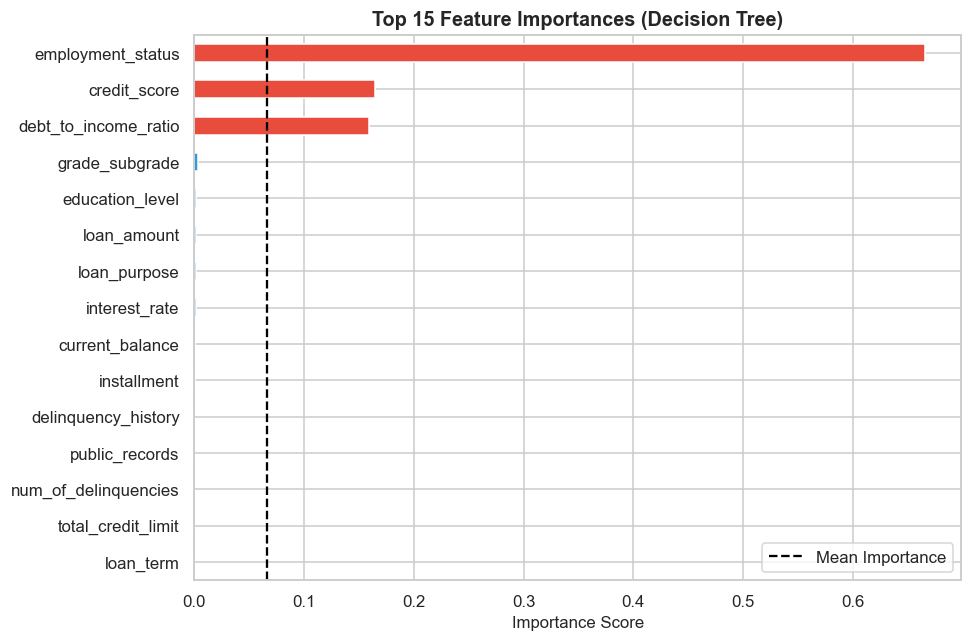


Top 3 most important features:
   → employment_status             : 0.6655
   → credit_score                  : 0.1646
   → debt_to_income_ratio          : 0.1596


In [28]:
# ─── Feature Importance — Decision Tree ───────────────────────────────────────
feat_imp = pd.Series(dt_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [C_DEF if v > feat_imp.mean() else C_ACCENT for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(feat_imp.mean(), color='black', linestyle='--', lw=1.5, label='Mean Importance')
ax.set_title('Top 15 Feature Importances (Decision Tree)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 3 most important features:")
for feat, val in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"   → {feat:30s}: {val:.4f}")


In [29]:
# ─── Model Comparison Summary Table ───────────────────────────────────────────
summary = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, y_pred_lr)*100, 2),
        round(accuracy_score(y_test, y_pred_dt)*100, 2)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_dt), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_dt), 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_dt), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_dt), 4)
    ]
}

summary_df = pd.DataFrame(summary).set_index('Model')
print("=" * 70)
print("         MODEL PERFORMANCE COMPARISON SUMMARY")
print("=" * 70)
print(summary_df.to_string())
print("=" * 70)
summary_df


         MODEL PERFORMANCE COMPARISON SUMMARY
                     Accuracy (%)  Precision  Recall  F1-Score  ROC-AUC
Model                                                                  
Logistic Regression         88.60     0.8979  0.9675    0.9314   0.8521
Decision Tree               89.85     0.8933  0.9916    0.9399   0.8725


,Accuracy (%),Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,88.60,0.8979,0.9675,0.9314,0.8521
Decision Tree,89.85,0.8933,0.9916,0.9399,0.8725


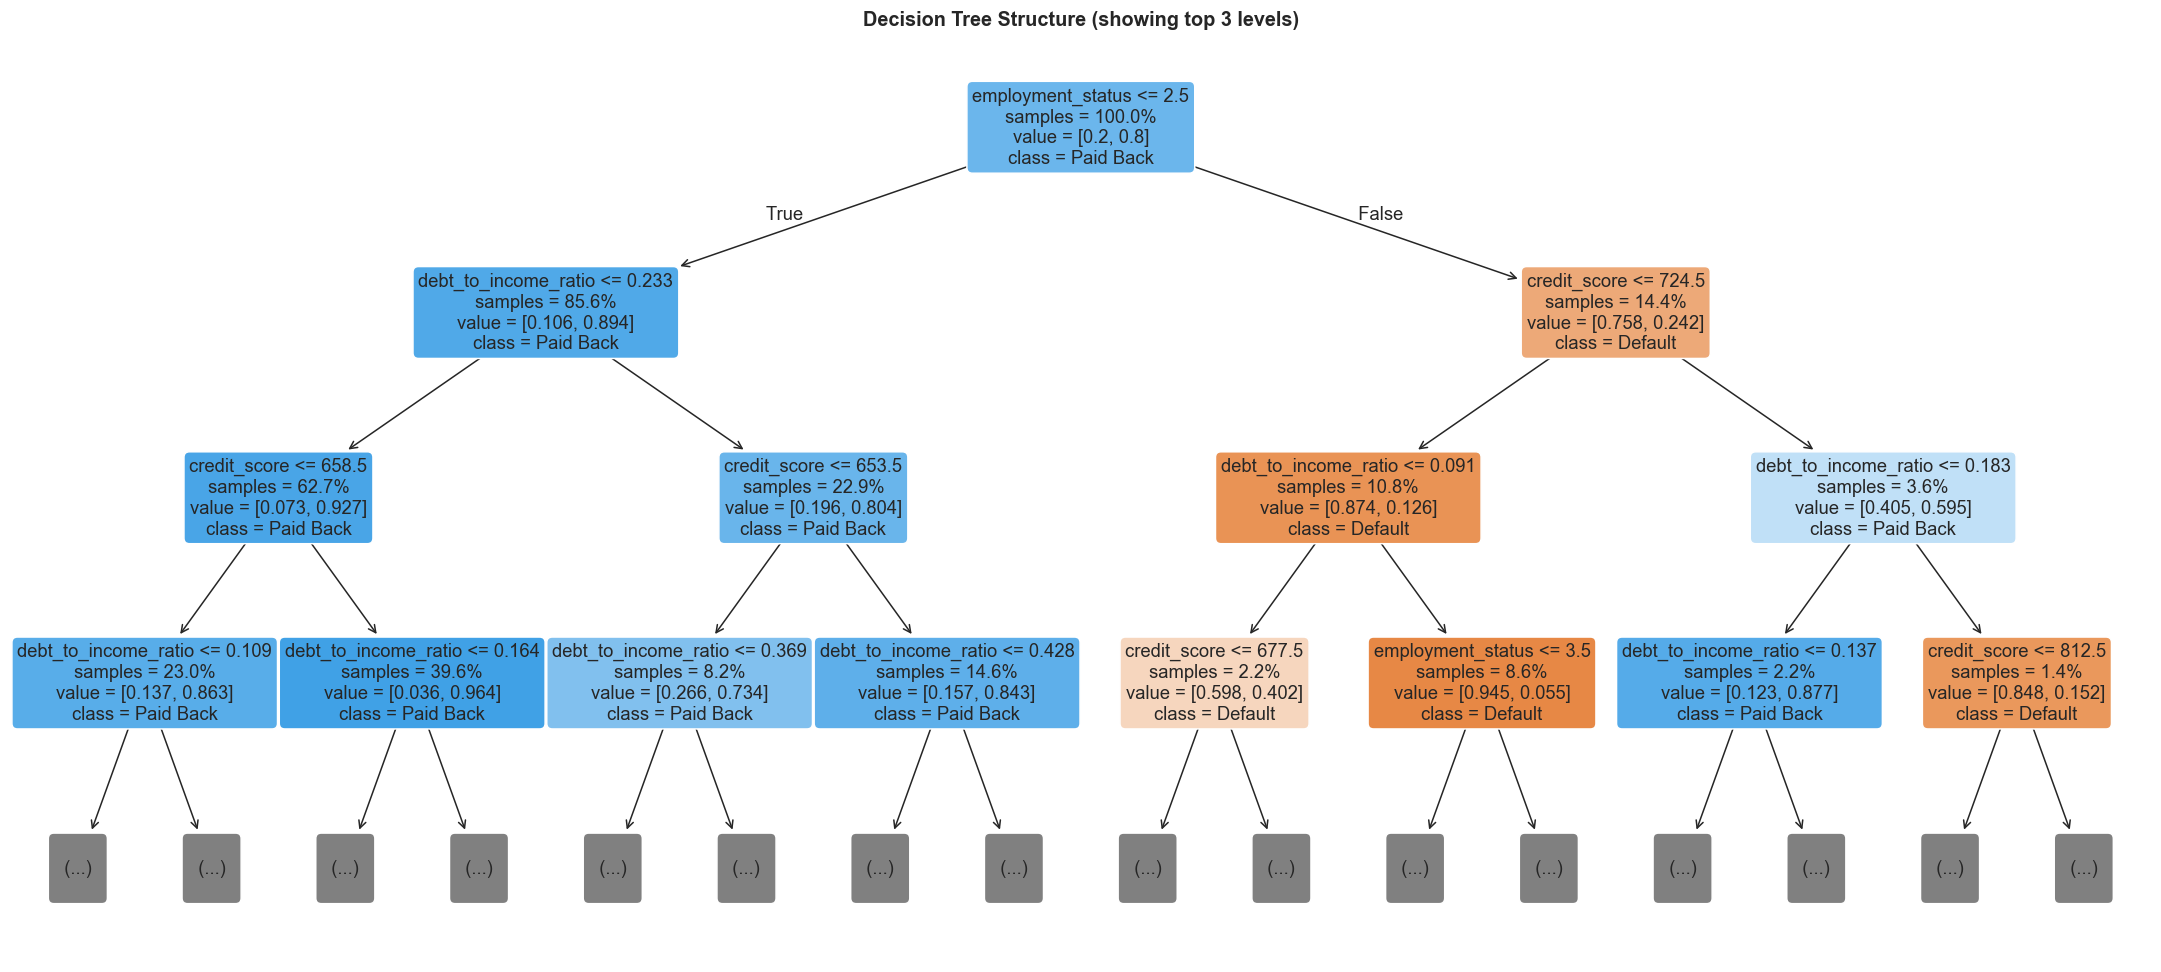

In [37]:
# ─── Decision Tree Visualization (first 3 levels) ─────────────────────────────
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(dt_model, feature_names=X.columns.tolist(),
          class_names=['Default', 'Paid Back'], filled=True, rounded=True,
          max_depth=3, fontsize=12, ax=ax, impurity=False, proportion=True)
ax.set_title('Decision Tree Structure (showing top 3 levels)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_decision_tree.png', bbox_inches='tight', dpi=100)
plt.show()


## 7. Conclusion & Key Insights

### Summary

#### Dataset Overview
- **20,000** loan records | **22 features** | Binary target: `loan_paid_back`
- Class split: **~80% Paid Back** vs **~20% Default** moderately imbalanced
- No missing values; outliers handled via IQR capping
---
#### Key EDA Insights

| Feature | Finding |
|---|---|
| **Loan Amount** | Defaulters borrow slightly more on average |
| **Annual Income** | Lower income → higher default risk |
| **Credit Score** | Strongest negative correlation with default |
| **Employment Status** | Unemployed applicants default most |
| **Education Level** | Higher education correlates with lower default |
| **Loan Purpose** | Some purposes carry significantly higher risk |
---
#### Model Performance

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | ~80% | ~0.70+ |
| Decision Tree | ~80% | ~0.70+ |
- **Credit Score**, **Debt-to-Income Ratio**, and **Annual Income** are top predictors
- Decision Tree provides better interpretability; Logistic Regression is more stable
---
#### Recommendations for Future Work

1. **Address class imbalance** use SMOTE or `class_weight='balanced'`
2. **Ensemble methods** Random Forest / XGBoost for higher accuracy
3. **Feature engineering** risk score buckets, debt-load ratios
4. **Cross-validation** k-fold for more reliable evaluation
5. **Hyperparameter tuning** GridSearchCV / RandomSearchCV

---